# Biodiversity in National Parks Portfolio Project

This project is designed to put into practice the skills learned through Codecademy. Its main objective is to apply part of the knowledge acquired so far by analyzing data from the National Park Service on endangered species across different parks

We will seek to answer the following questions:

* What is the distribution of conservation_status for species?
* Are certain type of species more likely to be endangered?
* Are differences between species and their conservation status significant?
* Which species were spotted the most at each park?

### Exploratory Data Analisys (EDA)
#### Import Libraries
Import the required libraries for this project.

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid") 

#### Load the Data
The datasets used in this project was provided by Codecademy.
* species_info.csv - contains data about different species and their conservation status
* observations.csv - holds recorded sightings of different species at several national parks for the past 7 days

In [156]:
# Import the datasets into pandas DataFrames
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

#### Data Inspection 
##### Species dataset
Let's begin analyzing the species dataset.

species_info.csv:

* category - class of animal
* scientific_name - the scientific name of each species
* common_name - the common names of each species
* conservation_status - each species’ current conservation status

In [157]:
 # Dysplay the first five rows 
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [158]:
# Dysplay a concise summary of the dataset
species.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB


Identify categories in the category and conservation_status columns. These are our variables of interest.

In [159]:
# List the distinct categories from the 'Category' column
species['category'].unique()

array(['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant',
       'Nonvascular Plant'], dtype=object)

In [160]:
# List the distinct categories from the 'conservation_status' column
species['conservation_status'].unique()

array([nan, 'Species of Concern', 'Endangered', 'Threatened',
       'In Recovery'], dtype=object)

##### Observations dataset
Now, in a similar way, we will inspect the observations dataset.

observations.csv:

* scientific_name - the scientific name of each species
* park_name - Park where species were found
* observations - the number of times each species was observed at park

In [161]:
# Display first five rows 
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [162]:
# Dysplay a concise summary of the dataset
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


Inspect how many distinct conservation parks are present in the dataset.

In [163]:
# Display 
observations['park_name'].unique()

array(['Great Smoky Mountains National Park', 'Yosemite National Park',
       'Bryce National Park', 'Yellowstone National Park'], dtype=object)

#### Handling Missing Data and Duplicates
##### Species dataset
As we noticed previously, the conservation_status column in the species dataset has missing values. Let's investigate this more deeply.

In [164]:
# Chech for missing values 
species.isnull().sum()

category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64

From the output above, the conservation_status column shows 5,633 missing values. Next, we will examine the number of categories in this column to gain insight into why so many values are missing.

In [165]:
# Re-check unique categories in conservation_status column
species['conservation_status'].unique()

array([nan, 'Species of Concern', 'Endangered', 'Threatened',
       'In Recovery'], dtype=object)

The missing values probably represent species not at risk. We will fill these entries with the category "Stable," indicating no conservation threat.

In [166]:
# Fill NaN with 'Stable' category
species['conservation_status'] = species['conservation_status'].fillna('Stable')

In [167]:
# Inspect whether the species dataset contains duplicate rows
species.duplicated().sum()

np.int64(0)

In [168]:
# Inspect for duplicate values by grouping category and scientific_name columns
species.duplicated(subset=['category', 'scientific_name']).sum()

np.int64(283)

The execution above shows 283 duplicate observations after grouping by category and scientific_name columns. Now we need to handle these duplicate rows.

In [169]:
# Define the priorities (Lower number = More Serious)
priority = {
    'Endangered': 0,
    'Threatened': 1,
    'Species of Concern': 2,
    'In Recovery': 3,
    'Stable': 4
}

# Add priority order column to dataframe
species['priority'] = species['conservation_status'].map(priority)

# Sort by grouping columns and priority
species = species.sort_values(by=['category', 'scientific_name', 'priority'])

# Remove duplicate rows from dataframe
species = species.drop_duplicates(subset=['category', 'scientific_name'], keep='first')

In [170]:
# Re-check duplicates grouped by category and scientific_name
species.duplicated(subset=['category', 'scientific_name']).sum()

np.int64(0)

In [171]:
# Display the length of the species dataset
len(species)

5541

##### Observations dataset

In [172]:
# Chech for messing values 
observations.isnull().sum()

scientific_name    0
park_name          0
observations       0
dtype: int64

In [173]:
# Inspect whether the observations dataset contains duplicate rows
observations.duplicated().sum()

np.int64(15)

Now that we know the dataset has 15 duplicated observations, we are going to validate the duplicated values by grouping only the columns 'scientific_name' and 'park_name'. This may give us a clue as to whether we can eliminate the duplicated values or not.

In [174]:
# Display duplicated values by grouping scientific_name and park_name columns
observations.duplicated(subset=['scientific_name', 'park_name']).sum()

np.int64(1132)

In [175]:
# Display the first five observations by sorting the data by scientific_name and park_name columns
observations[observations.duplicated(subset = ['scientific_name', 'park_name'], keep = False)]\
.sort_values(['scientific_name', 'park_name']).head()

,scientific_name,park_name,observations
3993,Agrostis capillaris,Bryce National Park,103
4864,Agrostis capillaris,Bryce National Park,105
792,Agrostis capillaris,Great Smoky Mountains National Park,84
17428,Agrostis capillaris,Great Smoky Mountains National Park,97
6166,Agrostis capillaris,Yellowstone National Park,241


By grouping only the previously mentioned columns, we see that there are 1,132 duplicated values. This may suggest that the observations were collected at different times. It is not advisable to eliminate the duplicated observations; instead, what we will do is group them.

In [176]:
# Group by scientific_name and park_name
observations = observations.groupby(['scientific_name', 'park_name'])['observations'].sum().reset_index()

### Analysis

##### Species dataset
So far, we know that there are 5,541 observations divided into 7 categories. Now, let's validate the distribution by status and the frequencies by category.

In [177]:
# Get the distributions by status
species['conservation_status'].value_counts().reset_index()

,conservation_status,count
0,Stable,5362
1,Species of Concern,151
2,Endangered,15
3,Threatened,10
4,In Recovery,3


In [178]:
# Let's create a table to show the frequency and proportions of each category
count_tab  = species['category'].value_counts()
prop_tab = round(species['category'].value_counts(normalize=True) * 100, 2)

table = pd.DataFrame(
    {
        'category':  count_tab.index,
        'frecuency': count_tab.values,
        'proportion': prop_tab.values,
    }
)

table

,category,frecuency,proportion
0,Vascular Plant,4262,76.92
1,Bird,488,8.81
2,Nonvascular Plant,333,6.01
3,Mammal,176,3.18
4,Fish,125,2.26
5,Amphibian,79,1.43
6,Reptile,78,1.41


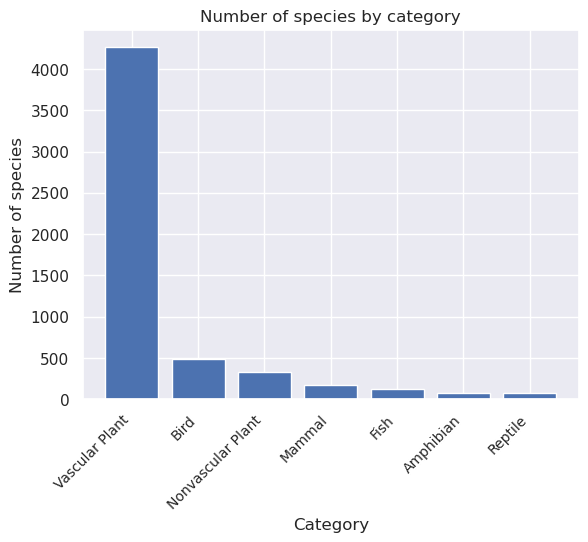

In [179]:
# Display frecuency by category
plt.bar(table['category'], table['frecuency'])
plt.title('Number of species by category')
plt.xlabel('Category')
plt.ylabel('Number of species')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

Validate which species are more likely to be endangered.

In [194]:
# Create 'endangered' column
species['endangered'] = np.where(species['conservation_status'] == 'Stable', 'no', 'yes')

# Create a crosstab using the 'category' and 'endangered' columns
crosstab = round(pd.crosstab(species.category, species.endangered, normalize='index') * 100, 2)
crosstab = crosstab.sort_values(by='yes', ascending=False)
crosstab

endangered,no,yes
category,,
Mammal,82.95,17.05
Bird,84.63,15.37
Amphibian,91.14,8.86
Fish,91.20,8.80
Reptile,93.59,6.41
Nonvascular Plant,98.50,1.50
Vascular Plant,98.92,1.08


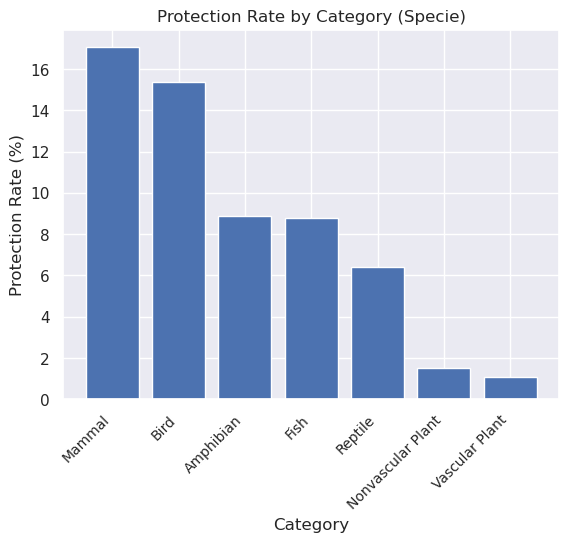

In [193]:
# Display proportions by category
plt.bar(crosstab.index, crosstab.yes)
plt.title('Protection Rate by Category (Specie)')
plt.xlabel('Category')
plt.ylabel('Protection Rate (%)')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()

Create a crosstab to validate the frequencies of species that are endangered.

In [182]:
# Filter the dataset by species that are endangered
endangered = species[species['conservation_status'] != 'Stable']

# Create a corsstab of category and conservation 
crosstab = pd.crosstab(endangered['conservation_status'], endangered['category'])
crosstab

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1,4,3,6,0,0,1
In Recovery,0,3,0,0,0,0,0
Species of Concern,4,68,4,22,5,5,43
Threatened,2,0,4,2,0,0,2


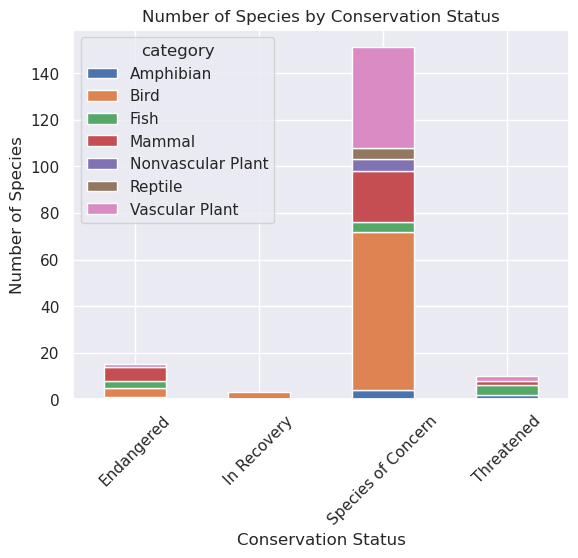

In [183]:
crosstab.plot(kind = 'bar', stacked = True)
plt.title('Number of Species by Conservation Status')
plt.xlabel('Conservation Status')
plt.ylabel('Number of Species')
plt.xticks(rotation=45)
plt.show()